In [4]:
from google.colab import files
uploaded = files.upload()


Saving Fake.csv to Fake.csv
Saving True.csv to True (1).csv


In [5]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("1. Loading raw datasets (Skipping bad lines)...")
fake_df = pd.read_csv('Fake.csv', on_bad_lines='skip', engine='python')
true_df = pd.read_csv('True.csv', on_bad_lines='skip', engine='python')

true_df['label'] = 1
fake_df['label'] = 0

print("2. Merging and Cleaning...")
combined_df = pd.concat([true_df, fake_df], ignore_index=True)
combined_df['cleaned_text'] = combined_df['text'].apply(clean_text)

# Drop any rows where cleaning left empty strings
combined_df = combined_df.dropna(subset=['cleaned_text'])

# Split the data
X = combined_df['cleaned_text']
y = combined_df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data ready! Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

1. Loading raw datasets (Skipping bad lines)...
2. Merging and Cleaning...
Data ready! Training samples: 35918 | Testing samples: 8980


1. Vectorizing text using TF-IDF...
2. Training Logistic Regression model...
3. Generating Evaluation Metrics...

--- Logistic Regression Evaluation ---
Accuracy:  0.9901

Classification Report:
              precision    recall  f1-score   support

    Fake (0)       0.99      0.99      0.99      4650
    Real (1)       0.99      0.99      0.99      4330

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



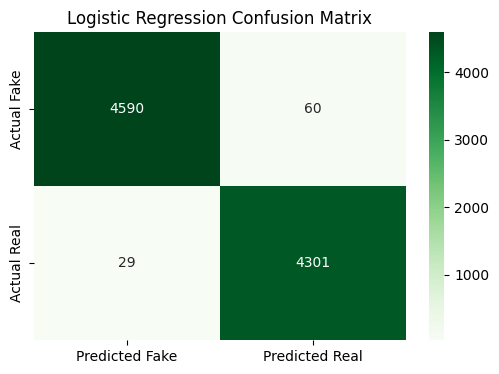

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("1. Vectorizing text using TF-IDF...")
tfidf_vectorizer = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("2. Training Logistic Regression model...")
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

print("3. Generating Evaluation Metrics...\n")
y_pred_lr = lr_model.predict(X_test_tfidf)

print("--- Logistic Regression Evaluation ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Fake (0)', 'Real (1)']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Fake', 'Predicted Real'],
            yticklabels=['Actual Fake', 'Actual Real'])
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [8]:
import joblib
# Save the Logistic Regression model
joblib.dump(lr_model, 'logistic_regression_model.pkl')
# Save the TF-IDF Vectorizer
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')
print("Logistic Regression model and vectorizer exported successfu ly!")

Logistic Regression model and vectorizer exported successfu ly!


In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
import numpy as np
import pickle

print("1. Tokenizing and Padding for LSTM...")
MAX_WORDS = 10000
MAX_LEN = 300

tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN,
padding='post')
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN,
padding='post')

y_train_np = np.array(y_train)
y_test_np = np.array(y_test)

print("2. Building LSTM Architecture...")
lstm_model = Sequential([
Embedding(input_dim=MAX_WORDS, output_dim=128),
LSTM(64, return_sequences=False),
Dropout(0.5),
Dense(32, activation='relu'),
Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("3. Training the LSTM Model...")
lstm_model.fit(X_train_pad, y_train_np, epochs=5, batch_size=64, validation_data=(X_test_pad,
y_test_np))

print("\n4. Evaluating LSTM...")
y_pred_probs = lstm_model.predict(X_test_pad)
y_pred_lstm = (y_pred_probs > 0.5).astype(int)

print("--- LSTM Evaluation ---")
print(f"Accuracy:  {accuracy_score(y_test_np, y_pred_lstm):.4f}")

# Save the LSTM model and tokenizer
lstm_model.save('truthguard_lstm.h5')
with open('lstm_tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("\nLSTM Model and Tokenizer saved successfuly!")

1. Tokenizing and Padding for LSTM...
2. Building LSTM Architecture...
3. Training the LSTM Model...
Epoch 1/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.7746 - loss: 0.4011 - val_accuracy: 0.9445 - val_loss: 0.1452
Epoch 2/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.9654 - loss: 0.1087 - val_accuracy: 0.9757 - val_loss: 0.0698
Epoch 3/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.9860 - loss: 0.0479 - val_accuracy: 0.9869 - val_loss: 0.0394
Epoch 4/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.9919 - loss: 0.0265 - val_accuracy: 0.9884 - val_loss: 0.0361
Epoch 5/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9977 - loss: 0.0107 - val_accuracy: 0.9696 - val_loss: 0.1015

4. Evaluating LSTM...
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


--- LSTM Evaluation ---
Accuracy:  0.9696

LSTM Model and Tokenizer saved successfuly!
